Loan amount:                 4,000,000.00 currency
Number of payments:                   360
Nominal interest rate:              5.40% p.a.
Payment frequency:                monthly
------------------------------------------------------------
Payment (no fees):            22,461.2317 currency
APR:                            5.553141%
Bisection converged in 37 steps

Amortization schedule (first 6 + last 5 rows):
 Period  Payment [currency]  Principal [currency]  Interest [currency]  Remaining debt [currency]
      0                 NaN                   NaN                  NaN               4.000000e+06
      1        22461.231675           4461.231675         18000.000000               3.995539e+06
      2        22461.231675           4481.307217         17979.924457               3.991057e+06
      3        22461.231675           4501.473100         17959.758575               3.986556e+06
      4        22461.231675           4521.729729         17939.501946               3.982034e

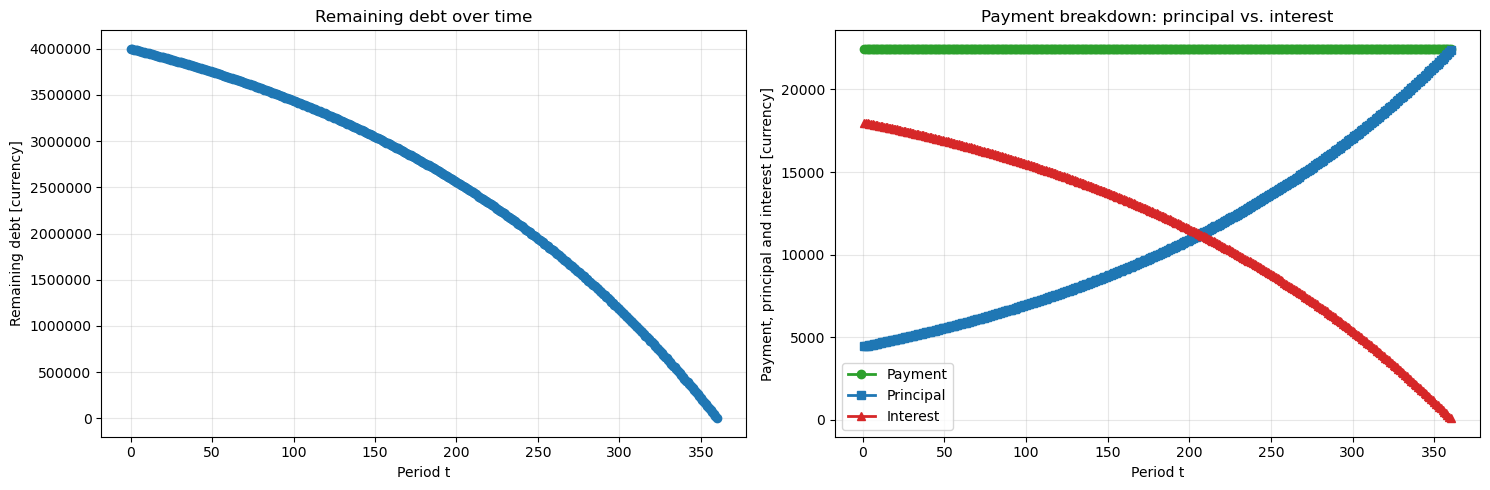

In [13]:
"""
Loan calculator — computes annuity payment, APR (Annual Percentage Rate)
using the bisection method, and the amortization schedule. Python equivalent
of the Excel workbook.

Usage:
    python loan_calculator.py             # run with default parameters and plot
    from loan_calculator import Loan      # or use as a module
"""

from __future__ import annotations

from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import pandas as pd


# --- payment frequency (payments per year) ---
FREQUENCY = {
    "weekly":     52,
    "monthly":    12,
    "quarterly":  4,
    "semiannual": 2,
    "annual":     1,
}


@dataclass
class Loan:
    # CORE PARAMETERS
    loan_amount: float = 4_000_000.0         # currency
    num_payments: int = 360
    annual_interest_rate: float = 0.054      # nominal p.a.
    payment_frequency: str = "monthly"       # key from FREQUENCY

    # ONE-OFF FEES ()
    origination_fee: float = 4_000.0        # paid at t=0
    termination_fee: float = 0.0            # paid in the last period

    # ONE-TIME FEE DURING THE LOAN (paid in a specific period)
    mid_term_fee: float = 500.0
    mid_term_fee_period: int = 4           # period number when it's paid

    mid_term_fee_2: float = 0.0
    mid_term_fee_2_period: int = 0

    # RECURRING FEES (currency per payment in the given frequency)
    recurring_fees: dict[str, float] = field(default_factory=lambda: {
        "weekly":     0.0,
        "monthly":    0.0,
        "quarterly":  0.0,
        "semiannual": 0.0,
        "annual":     200.0,
    })

    # ------------------------------------------------------------------
    # derived values
    # ------------------------------------------------------------------
    @property
    def periods_per_year(self) -> int:
        """Number of payments per year for the chosen frequency."""
        return FREQUENCY[self.payment_frequency]

    @property
    def period_rate(self) -> float:
        """Interest rate per payment period."""
        return self.annual_interest_rate / self.periods_per_year

    @property
    def loan_term_years(self) -> float:
        return self.num_payments / self.periods_per_year

    # ------------------------------------------------------------------
    # ANNUITY PAYMENT — without fees
    # ------------------------------------------------------------------
    def annuity_payment(self) -> float:
        i = self.period_rate
        n = self.num_payments
        S = self.loan_amount
        if i == 0:
            return S / n
        return S * i / (1 - (1 + i) ** (-n))

    # ------------------------------------------------------------------
    # APR — present-value equation solved by bisection
    # ------------------------------------------------------------------
    def _npv(self, annual_rate: float) -> float:
        """
        f(i) = loan amount − present value of all borrower payments.
        We're looking for i such that f(i) = 0 → that's the APR.
        """
        i = annual_rate
        S = self.loan_amount
        P = self.annuity_payment()
        n = self.num_payments
        term = self.loan_term_years

        # PV of payments (paid at the end of each period, in years t = k/p)
        pv_payments = sum(P / (1 + i) ** (k / self.periods_per_year)
                          for k in range(1, n + 1))

        # PV of one-off fees
        pv_fees = self.origination_fee  # at t = 0
        pv_fees += self.termination_fee / (1 + i) ** term

        if self.mid_term_fee and self.mid_term_fee_period > 0:
            t = self.mid_term_fee_period / self.periods_per_year
            pv_fees += self.mid_term_fee / (1 + i) ** t

        if self.mid_term_fee_2 and self.mid_term_fee_2_period > 0:
            t = self.mid_term_fee_2_period / self.periods_per_year
            pv_fees += self.mid_term_fee_2 / (1 + i) ** t

        # PV of recurring fees — separate series for each frequency
        for freq, amount in self.recurring_fees.items():
            if not amount:
                continue
            num_fee_payments = int(FREQUENCY[freq] * term)
            t_step = 1 / FREQUENCY[freq]  # in years
            pv_fees += sum(
                amount / (1 + i) ** (k * t_step)
                for k in range(1, num_fee_payments + 1)
            )

        return S - pv_payments - pv_fees

    def apr(
        self,
        a: float = 1e-10,
        b: float = 10.0,
        max_iter: int = 100,
        tol: float = 1e-10,
    ) -> tuple[float, pd.DataFrame]:
        """
        Bisection method — same algorithm as in the Excel workbook.
        Returns (apr, iteration table).
        """
        fa = self._npv(a)
        fb = self._npv(b)
        if fa * fb > 0:
            raise ValueError(
                f"Function doesn't change sign on [{a}, {b}] "
                f"(f(a)={fa}, f(b)={fb})."
            )

        rows = []
        for k in range(1, max_iter + 1):
            c = (a + b) / 2
            fc = self._npv(c)
            rows.append({"step": k, "A": a, "B": b, "midpoint": c,
                         "f(A)": fa, "f(B)": fb, "f(midpoint)": fc})

            if abs(fc) < tol or (b - a) / 2 < tol:
                break

            if fa * fc < 0:
                b, fb = c, fc
            else:
                a, fa = c, fc

        return c, pd.DataFrame(rows)

    # ------------------------------------------------------------------
    # AMORTIZATION SCHEDULE
    # ------------------------------------------------------------------
    def amortization_schedule(self) -> pd.DataFrame:
        i = self.period_rate
        P = self.annuity_payment()
        n = self.num_payments

        rows = [{"Period": 0, "Payment [currency]": None, "Principal [currency]": None,
                 "Interest [currency]": None, "Remaining debt [currency]": self.loan_amount}]

        balance = self.loan_amount
        for k in range(1, n + 1):
            interest = balance * i
            principal = P - interest
            balance = balance - principal
            rows.append({
                "Period": k,
                "Payment [currency]": P,
                "Principal [currency]": principal,
                "Interest [currency]": interest,
                "Remaining debt [currency]": max(balance, 0.0),
            })

        return pd.DataFrame(rows)


# ----------------------------------------------------------------------
# CHARTS (same as in the Excel workbook)
# ----------------------------------------------------------------------
def plot_remaining_debt(schedule: pd.DataFrame, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(schedule["Period"], schedule["Remaining debt [currency]"],
            marker="o", color="#1f77b4", linewidth=2)
    ax.set_title("Remaining debt over time")
    ax.set_xlabel("Period t")
    ax.set_ylabel("Remaining debt [currency]")
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(style="plain", axis="y")
    return ax


def plot_payment_breakdown(schedule: pd.DataFrame, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 5))
    # first row (period 0) has no payment data
    s = schedule.dropna(subset=["Payment [currency]"])
    ax.plot(s["Period"], s["Payment [currency]"],
            marker="o", label="Payment", color="#2ca02c", linewidth=2)
    ax.plot(s["Period"], s["Principal [currency]"],
            marker="s", label="Principal", color="#1f77b4", linewidth=2)
    ax.plot(s["Period"], s["Interest [currency]"],
            marker="^", label="Interest", color="#d62728", linewidth=2)
    ax.set_title("Payment breakdown: principal vs. interest")
    ax.set_xlabel("Period t")
    ax.set_ylabel("Payment, principal and interest [currency]")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.ticklabel_format(style="plain", axis="y")
    return ax


# ----------------------------------------------------------------------
def main():
    loan = Loan()

    P = loan.annuity_payment()
    apr_value, iterations = loan.apr()
    schedule = loan.amortization_schedule()

    print("=" * 60)
    print(f"Loan amount:              {loan.loan_amount:>15,.2f} currency")
    print(f"Number of payments:       {loan.num_payments:>15d}")
    print(f"Nominal interest rate:    {loan.annual_interest_rate:>15.2%} p.a.")
    print(f"Payment frequency:        {loan.payment_frequency:>15s}")
    print("-" * 60)
    print(f"Payment (no fees):        {P:>15,.4f} currency")
    print(f"APR:                      {apr_value:>15.6%}")
    print(f"Bisection converged in {len(iterations)} steps")
    print("=" * 60)

    print("\nAmortization schedule (first 6 + last 5 rows):")
    print(pd.concat([schedule.head(6), schedule.tail(5)]).to_string(index=False))

    # plot charts side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    plot_remaining_debt(schedule, ax1)
    plot_payment_breakdown(schedule, ax2)
    fig.tight_layout()
    fig.savefig("loan_calculator_charts.png", dpi=120, bbox_inches="tight")
    print("\nCharts saved to loan_calculator_charts.png")
    plt.show()


if __name__ == "__main__":
    main()